In [60]:
## Unifys the activity scale for all proteins

# Read in data frame 
# Scale for diffren data sets
## Imin Reductase Sigmoid scaling -> read out max and min values
## Try_B -> read out max and min values

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
df = pd.read_csv('/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/files_index/1_Imin_Reductase_two_to_many_id.csv')
out_dir = '/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/uni_scale/1_Imin_Reductase_two_to_many_id.csv'
# df = pd.read_csv('/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/files_index/2_Alpha_Amylase_close_to_far_id.csv')
# out_dir = '/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/uni_scale/1_Alpha_Amylase_by_mutation_id.csv'
# df = pd.read_csv('/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/files_index/1_Try_B_by_position_id.csv')
# out_dir = '/home/lherrmann/projects/enzyme-design/flip2_Project/test/csv_id/uni_scale/1_Try_B_by_position_id.csv'

In [63]:
df.head()
print(df['target'].min())
print(df['target'].max())


-4.841122414314039
4.764113104268745


<Axes: xlabel='target', ylabel='Count'>

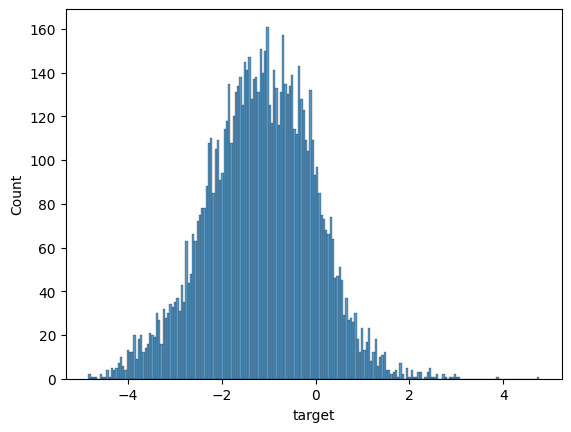

In [64]:
sns.histplot(df, x='target', bins = 200)

In [65]:
x1 = df['target'].min()
y1 = df['target'].max()

print(df['target'].max())
print(df['target'].min())
print(df['target'].unique())

4.764113104268745
-4.841122414314039
[-2.06990548e+00 -2.25208071e+00 -1.51426160e-03 ... -2.03982359e+00
 -1.05305784e+00 -7.07686719e-01]


In [66]:
# from scipy.stats import gaussian_kde

#     # """
#     # Finds the active/inactive cutoff by modelling the inactive population.

#     # The left half of the distribution is purely inactive (no contamination from actives).
#     # Mirror it to reconstruct a symmetric inactive Gaussian, then cut at mean + k*std.
#     # k=2 captures ~97.7% of inactives; increase k to be more conservative.
#     # Works for both a sharp inactive peak (Alpha Amylase) and a broad Gaussian inactive cluster (Try_B).
#     # """
# def TryB_ina_cut(data, k=2, bandwidth='scott'):
#     data = np.array(data)
#     kde = gaussian_kde(data, bw_method=bandwidth)
#     x = np.linspace(data.min(), data.max(), 2000)
#     y = kde(x)

#     # Peak of the inactive cluster
#     peak_x = x[np.argmax(y)]

#     # Left side only (pure inactives), mirrored to reconstruct the full symmetric Gaussian
#     left = data[data <= peak_x]
#     mirrored = np.concatenate([left, 2 * peak_x - left])

#     mean = mirrored.mean()  # ≈ peak_x
#     std = mirrored.std()
#     cutoff = mean + k * std

#     # Plot to verify
#     fig, ax = plt.subplots()
#     sns.histplot(data, bins=200, ax=ax, stat='density')
#     ax.plot(x, y, color='orange', linewidth=2, label='KDE')
#     ax.axvline(cutoff, color='red', linestyle='--', label=f'cutoff = {cutoff:.4f}  (mean + {k}σ)')
#     ax.legend()
#     plt.show()

#     return cutoff

# dead_peak = find_local_minimum(df['target'])

In [67]:
# # Try_B_assay, gaussian scaling
# #in vivo competitive assay, linear scaling
# def TryB_ina_cut(linear_scor_array, dead_peak_val=dead_peak):
#     data = np.array(linear_scor_array)
#     ceiling = data.max()
#     normalized = (data - dead_peak_val) / (ceiling - dead_peak_val)
#     return np.clip(normalized, 0, 1)


# df['uni_scale'] = TryB_ina_cut(df['target'])

In [68]:
# Imin Reductase Sigmoid scaling
# Centered around 0 = WT activity, 
def unify_ired(log_scores_array, k=1.0):
    log_scores = np.array(log_scores_array)    
    # Apply the sigmoidal transformation
    unified_scores = 1 / (1 + np.exp(-k * log_scores))
    
    return unified_scores

#IRED add uniscale
df['uni_scale'] = unify_ired(df['target'])
df.head(1)
print(df['target'].max())
print(df['target'].min())
print(df['uni_scale'].max())
print(df['uni_scale'].min())

4.764113104268745
-4.841122414314039
0.991541702578961
0.0078362915668053


In [69]:
# #Alpha amylase
# def find_inac_cutoff(data, bandwidth='scott'):
#     """
#     Finds active/inactive cutoff via the KDE inflection point.
#     For a distribution with one sharp inactive peak + active tail:
#     looks at the right descending slope of the main peak and finds
#     where the curve transitions from steep decline into the flat tail
#     (= the inflection point = minimum of the first derivative).
#     """
#     from scipy.stats import gaussian_kde

#     data = np.array(data)
#     kde = gaussian_kde(data, bw_method=bandwidth)
#     x = np.linspace(data.min(), data.max(), 2000)
#     y = kde(x)

#     # Right side of the main (inactive) peak only
#     main_peak_idx = np.argmax(y)
#     x_right = x[main_peak_idx:]
#     y_right = y[main_peak_idx:]

#     # Inflection point = minimum of the first derivative on the descending slope
#     dy = np.gradient(y_right, x_right)
#     cutoff = x_right[np.argmin(dy)]

#     # Plot to verify
#     fig, ax = plt.subplots()
#     sns.histplot(data, bins=50, ax=ax, stat='density', )
#     ax.plot(x, y, color='orange', linewidth=2, label='KDE')
#     ax.axvline(cutoff, color='red', linestyle='--', label=f'cutoff = {cutoff:.4f}')
#     ax.legend()
#     plt.show()

#     return cutoff


# dead_peak = find_inac_cutoff(df['target'])
# print(dead_peak)

In [70]:
# # Alpha Amylase
# #stain removel assay, linear scaling
# def unify_alpha_amylase(linear_scor_array, dead_peak_val=dead_peak):
#     data = np.array(linear_scor_array)
#     ceiling = data.max()
#     normalized = (data - dead_peak_val) / (ceiling - dead_peak_val)
#     return np.clip(normalized, 0, 1)


# df['uni_scale'] = unify_alpha_amylase(df['target'])


In [71]:
df.head()

,id,sequence,set,validation,target,uni_scale
0,1IR_000001,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,-2.069905,0.112056
1,1IR_000002,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,-2.252081,0.095170
2,1IR_000003,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,-0.001514,0.499621
3,1IR_000004,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,-3.156107,0.040851
4,1IR_000005,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,-1.290394,0.215786


In [72]:
# sns.histplot(df, x='uni_scale', bins = 40)
counts_uni = (df['uni_scale'] == 0).value_counts()
print(counts_uni)

uni_scale
False    8586
Name: count, dtype: int64


In [73]:
# sns.countplot(x=(df['target'] >= dead_peak))
counts = (df['target'] >= dead_peak).value_counts()
print(counts)

target
False    7390
True     1196
Name: count, dtype: int64


In [74]:
df1 = df.drop('target', axis =1)
df1 = df1[['id','sequence','set','validation','uni_scale']]
df1.head()

,id,sequence,set,validation,uni_scale
0,1IR_000001,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,0.112056
1,1IR_000002,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,0.095170
2,1IR_000003,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,0.499621
3,1IR_000004,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,0.040851
4,1IR_000005,MRDTDVTVLGLGLMGQALAGAFLKDGHATTVWNRSEGKAGQLAEQG...,train,False,0.215786


In [75]:
df1['uni_scale'].max()
df1['uni_scale'].min()

np.float64(0.0078362915668053)

In [76]:
df1.to_csv(out_dir, index=False)